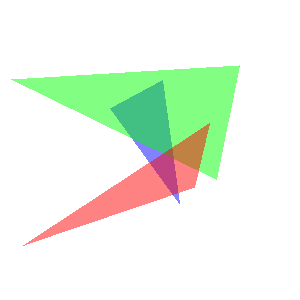

In [124]:
from PIL import Image, ImageDraw

polygons = [
    {'vertices': [(179, 203), (162, 80), (110, 108)],
     'RGBA': (0, 0, 255, 125)},
    {'vertices': [(239, 65), (216, 179), (11, 79)], 'RGBA': (0, 255, 0, 125)},
    {'vertices': [(209, 123), (23, 245), (194, 187)], 'RGBA': (255, 0, 0, 125)}
]


def draw(polygons, size):
    """ Функция для рисования многоугольников """

    img = Image.new('RGB', (size[0], size[1]), (255, 255, 255))
    drw = ImageDraw.Draw(img, 'RGBA')

    for pol in polygons:
        drw.polygon(pol['vertices'], pol['RGBA'])

    return (img.convert("RGB"))


draw(polygons, size=(300, 300))

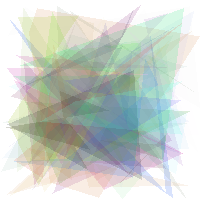

In [125]:
import numpy as np


def random_triangles(N, size, vertices=3, colour="random", alpha="random"):
    """ Функция создания популяции рандомных треугольников """

    collection = []

    for i in range(N):
        coords = [(np.random.randint(0, size[0]), np.random.randint(0, size[1]))
                  for i in range(vertices)]

        if alpha == "random":
            a = np.random.randint(0, 50)
        else:
            a = alpha

        if colour == "white":
            rgba = (255, 255, 255, a)
        elif colour == "black":
            rgba = (0, 0, 0, a)
        elif colour == "random":
            rgba = (np.random.randint(0, 256), np.random.randint(
                0, 256), np.random.randint(0, 256), a)

        triangle = {"vertices": coords, "RGBA": rgba}
        collection.append(triangle)

    return (collection)


collection = random_triangles(N=50, size=(
    200, 200), vertices=5, colour="random", alpha="random")
img = draw(collection, size=(200, 200))
img

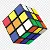

In [126]:
image_path = "images/cube.png"
target = Image.open(image_path).convert("RGB")
target

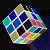

In [127]:
from PIL import ImageChops

ImageChops.difference(img, target)

In [128]:
def pixel_difference(candidate, target):
    """ Функция для попиксельного вычисления отличий между картинками"""
    diff = ImageChops.difference(candidate, target)
    totdiff = np.array(diff.get_flattened_data()).sum()
    return (totdiff)


diff = pixel_difference(img, target)
diff

np.int64(502557)

In [129]:
def max_pixel_difference(target):
    """ Функция вычисления максимально возможной разницы между изображениями"""
    white = Image.new('RGB', target.size, (255, 255, 255))
    diff = ImageChops.difference(white, target)
    maxdiff = np.array(diff.get_flattened_data()).sum()
    return (maxdiff)


maxdiff = max_pixel_difference(target)
fitness = (1 - diff / maxdiff) * 100
print("Fitness = " + str(np.round(fitness, 4)) + "%")

Fitness = 5.698%


In [130]:
import copy
import matplotlib.pyplot as plt


def mutation(original, size):
    """ Функция мутации"""
    mutant = copy.deepcopy(original)
    polidx = np.random.randint(len(mutant))

    #######################################

    polygon = mutant[polidx]
    mutation_type = np.random.choice(['vertex', 'colour', 'alpha', 'insert', 'delete'])

    if mutation_type == 'vertex':
        # сдвигаем случайную вершину на небольшое случайное расстояние
        vidx = np.random.randint(len(polygon['vertices']))
        x, y = polygon['vertices'][vidx]
        
        x = int(np.clip(x + np.random.randint(-30, 31), -10, size[0] + 10))
        y = int(np.clip(y + np.random.randint(-30, 31), -10, size[1] + 10))
        
        polygon['vertices'][vidx] = (x, y)

    elif mutation_type == 'colour':
        # изменяем один из каналов R, G или B
        channel = np.random.randint(3)
        
        rgba = list(polygon['RGBA'])
        rgba[channel] = int(np.clip(rgba[channel] + np.random.randint(-40, 41), 0, 255))
        
        polygon['RGBA'] = tuple(rgba)

    elif mutation_type == 'alpha': 
        # изменяем прозрачность
        rgba = list(polygon['RGBA'])
        rgba[3] = int(np.clip(rgba[3] + np.random.randint(-20, 21), 0, 255))
        
        polygon['RGBA'] = tuple(rgba)

    elif mutation_type == 'insert':
        # вставка нового случайного многоугольника в случайную позицию
        new_pol = random_polygons(1, size)[0]
        idx = np.random.randint(0, len(mutant) + 1)

        mutant.insert(idx, new_pol)

    else: # удаление случайного многоугольника
        if len(mutant) > 1:
            mutant.pop(polidx)

    return mutant

In [131]:
def pop_fitness(pop, target):
    """
    Вычисляет приспособленность каждой популяции
    """

    size = target.size
    maxdiff = max_pixel_difference(target)

    fitvec = []

    for org in pop:
        img = draw(org[0], size)
        diff = pixel_difference(img, target)
        fitness = (1 - diff / maxdiff) * 100
        fitvec.append(fitness)

    return (fitvec)


def individ_fitness(individ, target):
    """
    Вычисление приспособленности индивида
    """

    size = target.size
    maxdiff = max_pixel_difference(target)

    img = draw(individ, size)
    diff = pixel_difference(img, target)
    fitness = (1 - diff / maxdiff) * 100

    return (fitness)

In [132]:
def random_polygons(N, size, num_verts=3, colour="random", alpha="random"):
    """ Создание рандомных многоугольников """

    collection = []

    for i in range(N):
        coords = [(np.random.randint(-10, size[0]+10),
                   np.random.randint(-10, size[1]+10)) for i in range(num_verts)]

        if alpha == "random":
            a = np.random.randint(0, 50)
        else:
            a = alpha

        if colour == "white":
            rgba = (255, 255, 255, a)
        elif colour == "black":
            rgba = (0, 0, 0, a)
        elif colour == "random":
            rgba = (np.random.randint(0, 256), np.random.randint(
                0, 256), np.random.randint(0, 256), a)

        triangle = {"vertices": coords, "RGBA": rgba}
        collection.append(triangle)

    return (collection)


def create_pop(Npop, N, size, num_verts=3, colour_init="black", alpha_init=100):
    """
    Создание популяции рандомных особей
    Каждая особь имеет N рандомно созданных многоугольников
    """

    pop = []
    for i in range(Npop):
        individ = random_polygons(
            N, size, num_verts=num_verts, colour=colour_init, alpha=alpha_init)
        fitness = individ_fitness(individ, target)
        pop.append((individ, fitness))

    pop = sorted(pop, key=lambda x: (x[1]), reverse=True)
    return pop


pop = create_pop(Npop=20, N=100, size=(200, 200), num_verts=2,
                 colour_init="random", alpha_init="random")

In [133]:
def crossover(parent1, parent2, size, pmut=0.1):
    """
    Функция кроссинговера
    """

    #####################

    # точка разрезки — случайный индекс от 1 до конца
    min_len = min(len(parent1), len(parent2))
    point = np.random.randint(1, min_len)

    # потомок: начало от первого родителя, конец от второго
    child = copy.deepcopy(parent1[:point]) + copy.deepcopy(parent2[point:])

    # с вероятностью pmut применяем мутацию
    if np.random.random() < pmut:
        child = mutation(child, size)

    return child

In [134]:
def tournament_selection(pop, k=3):
    """
    Турнирный отбор: случайно выбираем k особей,
    возвращаем лучшую из них.
    k — размер турнира, обычно 2-5.
    """
    
    contestants = np.random.choice(len(pop), size=k, replace=False)
    best_idx = max(contestants, key=lambda i: pop[i][1])
    
    return pop[best_idx][0]

def new_generation(pop, fitness, size, pmut=0.1, num_of_olds=0.5, selection='elite'):
    """Функция создания нового (следующего) поколения"""

    Npop = len(pop)

    # обновляем fitness в популяции и сортируем по убыванию
    updated = sorted(
        [(pop[i][0], fitness[i]) for i in range(Npop)],
        key=lambda x: x[1],
        reverse=True
    )

    # сколько лучших особей оставляем без изменений
    # n_old = max(1, int(Npop * num_of_olds))
    # new_pop = list(updated[:n_old])

    # пул родителей — верхняя половина популяции
    # pool_size = max(2, Npop // 2)

    children = []
    
    # заполняем оставшиеся места потомками
    while len(children) < Npop:
        # idx1, idx2 = np.random.choice(pool_size, size=2, replace=False)
        
        # child = crossover(updated[idx1][0], updated[idx2][0], size, pmut=pmut)
        # child_fit = individ_fitness(child, target)
        
        # new_pop.append((child, child_fit))
        parent1 = tournament_selection(updated, k=3)
        parent2 = tournament_selection(updated, k=3)

        child = crossover(parent1, parent2, size, pmut=pmut)
        
        # new_pop.append((child, 0.0))
        children.append(child)

    if selection == 'elite':
        # лучшие num_of_olds переходят, остальные — потомки
        n_old = max(1, int(Npop * num_of_olds))
        newpop = list(updated[:n_old])
        
        for child in children[:Npop - n_old]:
            newpop.append((child, 0.0))

    elif selection == 'uniform':
        # все родители переходят, затем случайные заменяются потомками
        newpop = list(updated)
        n_replace = max(1, int(Npop * (1 - num_of_olds)))
        
        replace_idx = np.random.choice(Npop, size=n_replace, replace=False)
        
        for i, idx in enumerate(replace_idx):
            newpop[idx] = (children[i], 0.0)

    newpop.sort(key=lambda x: x[1], reverse=True)
    
    return newpop

In [135]:
import pandas as pd
import time


def mean(list):
    sum = 0
    for elem in list:
        sum += elem[1]
    return sum/len(list)


def genetic_triangle_painting(
    target, 
    Npop, 
    Ntri=100, 
    num_verts=3, 
    maxgen=10, 
    every=20, 
    pmut=0.1, 
    num_of_olds=0.1, 
    colour_init="random", 
    alpha_init="random", 
    selection="elite",
    logs=True, 
    outdir="output_images"
):
    size = target.size

    pop_time = time.time()
    pop = create_pop(Npop=Npop, N=Ntri, size=size, num_verts=num_verts,
                     colour_init=colour_init, alpha_init=alpha_init)
    fitness = pop_fitness(pop, target)
    pop_time = time.time() - pop_time

    info = []
    maxfit = 0

    for i in range(maxgen+1):
        maxfit = pop[0][1]
        if i % every == 0:
            avgfit = mean(pop)

            best = pop[0][0]
            best_img = draw(best, size=size)
            outpath = outdir + "/generation_" + str(i) + ".png"
            best_img.save(outpath)
            info.append([i, maxfit, avgfit, pop_time, outpath])
            if logs == True:
                print("Generation: " + str(i) + "    Max. Fitness: " + str(np.round(maxfit, 2)) +
                      "%    Avg. Fitness: " + str(np.round(avgfit, 2)) + "%" + "   Time: "+str(pop_time))

        pop_time = time.time()

        # адаптивная мутация: если популяция сошлась — увеличиваем мутацию
        if maxfit > 0:
            convergence = (maxfit - mean(pop)) / maxfit
            adaptive_pmut = pmut + (1 - convergence) * 0.4
        else:
            adaptive_pmut = pmut
        
        newpop = new_generation(pop, fitness, size=size,
                                pmut=adaptive_pmut, num_of_olds=num_of_olds, selection=selection)

        # newpop = new_generation(pop, fitness, size=size,
        #                         pmut=pmut, num_of_olds=num_of_olds, selection=selection)
        
        fitness = pop_fitness(newpop, target)
        pop_time = time.time() - pop_time
        # pop = newpop
        pop = [(newpop[i][0], fitness[i]) for i in range(len(newpop))]

    dfout = pd.DataFrame(
        info, columns=["generation", "max_fitness", "avg_fitness", "time", "outpath"])
    return (dfout)

In [136]:
import os

os.makedirs("output_images_cube_uniform", exist_ok=True)

df = genetic_triangle_painting(
    target=target,
    Npop=50, # размер популяции
    Ntri=200, # количество многоугольников в одной особи
    num_verts=4, 
    maxgen=2000, # число поколений
    every=50,
    pmut=0.3, # вероятность мутации потомка после кроссинговера
    num_of_olds=0.05,
    colour_init="random",
    alpha_init="random",
    selection="uniform",
    logs=True,
    outdir="output_images_cube_uniform"
)

Generation: 0    Max. Fitness: -15.52%    Avg. Fitness: -22.74%   Time: 0.2121260166168213
Generation: 50    Max. Fitness: 11.48%    Avg. Fitness: 10.64%   Time: 0.09918403625488281
Generation: 100    Max. Fitness: 22.47%    Avg. Fitness: 22.34%   Time: 0.08321881294250488
Generation: 150    Max. Fitness: 30.9%    Avg. Fitness: 30.88%   Time: 0.0810699462890625
Generation: 200    Max. Fitness: 35.32%    Avg. Fitness: 35.32%   Time: 0.08150792121887207
Generation: 250    Max. Fitness: 39.23%    Avg. Fitness: 39.25%   Time: 0.07969903945922852
Generation: 300    Max. Fitness: 41.91%    Avg. Fitness: 41.82%   Time: 0.08269882202148438
Generation: 350    Max. Fitness: 43.98%    Avg. Fitness: 43.87%   Time: 0.08312606811523438
Generation: 400    Max. Fitness: 45.94%    Avg. Fitness: 45.84%   Time: 0.08531618118286133
Generation: 450    Max. Fitness: 47.21%    Avg. Fitness: 47.21%   Time: 0.08054780960083008
Generation: 500    Max. Fitness: 47.92%    Avg. Fitness: 47.92%   Time: 0.0823459625